SECTION 1-DATA QUALITY CHECK 

In [5]:
import pandas as pd
import numpy as np

# 1. Loading data and forcing clean empty values to NaN, but KEEP 'None' for loyalty tier (Footnote 7)
df = pd.read_csv('D:/Samad/Data_Analysis-Project/Travclan-Hotel-Booking-Project/TA-2/code/hotel bookings flat.csv', keep_default_na=False, na_values=['', 'NaN', 'nan'])

# 2. Pre-processing dates
df['booking_date'] = pd.to_datetime(df['booking_date'], errors='coerce')
df['customer_signup_date'] = pd.to_datetime(df['customer_signup_date'], errors='coerce')
df['checkin_date'] = pd.to_datetime(df['checkin_date'], errors='coerce')
df['checkout_date'] = pd.to_datetime(df['checkout_date'], errors='coerce')
df['num_rooms'] = pd.to_numeric(df['num_rooms'], errors='coerce')

# --- C1: Zero rooms check ---
zero_bookings = df[df['num_rooms'] == 0]
print(f"C1: Found {len(zero_bookings)} bookings with num_rooms = 0.")
print("Implication: The upstream pipeline might be logging incomplete cart checkouts as full bookings, or there's a missing-data default issue.\n")

# --- C2: Booking before account ---
early_bookings = df[df['booking_date'] < df['customer_signup_date']]
print(f"C2: Found {len(early_bookings)} bookings where booking_date is earlier than customer_signup_date.")
print("Plausible explanations: \n1) Guest booked as 'guest' and created an account later (temporal mismatch).\n2) Timezone conversion issues during logging.\n")

# --- C3: Review Missingness ---
df['missing_review'] = df['review_rating'].isna()
missing_reviews_total = df['missing_review'].mean() * 100
missing_reviews_by_status = df.groupby('booking_status')['missing_review'].mean() * 100
print(f"C3: Overall, {missing_reviews_total:.2f}% of bookings have no review.")
print("Percentage of missing reviews by status:")
print(missing_reviews_by_status)
print("\nPattern Check: Yes, this makes sense. No-Shows and Cancelled bookings should logically have near 100% missing reviews since the stay never occurred.\n")

# --- Footnote 1 & 5: Flagging data errors ---
invalid_stays = df[df['checkout_date'] <= df['checkin_date']]
print(f"FOOTNOTE 1 ALERT: Found {len(invalid_stays)} invalid stay bookings (checkout <= checkin).")

cancelled_with_reviews = df[(df['booking_status'] == 'Cancelled') & (df['review_rating'].notna())]
print(f"FOOTNOTE 5 ALERT: Found {len(cancelled_with_reviews)} Cancelled bookings that carry a review_rating. These are impossible.")

C1: Found 60 bookings with num_rooms = 0.
Implication: The upstream pipeline might be logging incomplete cart checkouts as full bookings, or there's a missing-data default issue.

C2: Found 163 bookings where booking_date is earlier than customer_signup_date.
Plausible explanations: 
1) Guest booked as 'guest' and created an account later (temporal mismatch).
2) Timezone conversion issues during logging.

C3: Overall, 57.12% of bookings have no review.
Percentage of missing reviews by status:
booking_status
Cancelled     97.827976
Completed     45.398050
No-Show      100.000000
Name: missing_review, dtype: float64

Pattern Check: Yes, this makes sense. No-Shows and Cancelled bookings should logically have near 100% missing reviews since the stay never occurred.

FOOTNOTE 1 ALERT: Found 120 invalid stay bookings (checkout <= checkin).
FOOTNOTE 5 ALERT: Found 50 Cancelled bookings that carry a review_rating. These are impossible.


SECTION 2- CASE STUDY

C:\Windows\Temp\ipykernel_2976\1849373456.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cancel_rates = df.groupby('is_vip').apply(lambda x: (len(x[x['booking_status'] == 'Cancelled']) / len(x)) * 100)


========== SECTION 2 CALCULATIONS ==========
Top 10% Threshold Size: 80 customers
Overlap - All Three Sets: 10 customers
Overlap - Exactly Two Sets: 54 customers
Overlap - Only One Set: 102 customers

VIP Share of Platform Realized Revenue: 26.84%
VIP Cancel Rate: 17.06% vs Non-VIP: 19.45%
VIP Avg Discount: ₹3967.06 vs Non-VIP: ₹1439.99

Acquisition: Budget acquires 1666 new customers.
Gross LTV: ₹614,045,516.03 | Year 1 Revenue: ₹122,809,103.21
Retention: Budget can theoretically retain 10000 customers.
Actual VIP Base size: 80 customers.
Assumption: The retention computation assumes 100% of the budget goes directly to specific ₹500 discount offers and ignores variable overhead.

Sensitivity Matrix (Profitability per VIP):
Retention_Cost            300            500            800
CAC                                                        
1000            366674.739513  366074.739513  365174.739513
2000            365674.739513  365074.739513  364174.739513
3000            364674.739

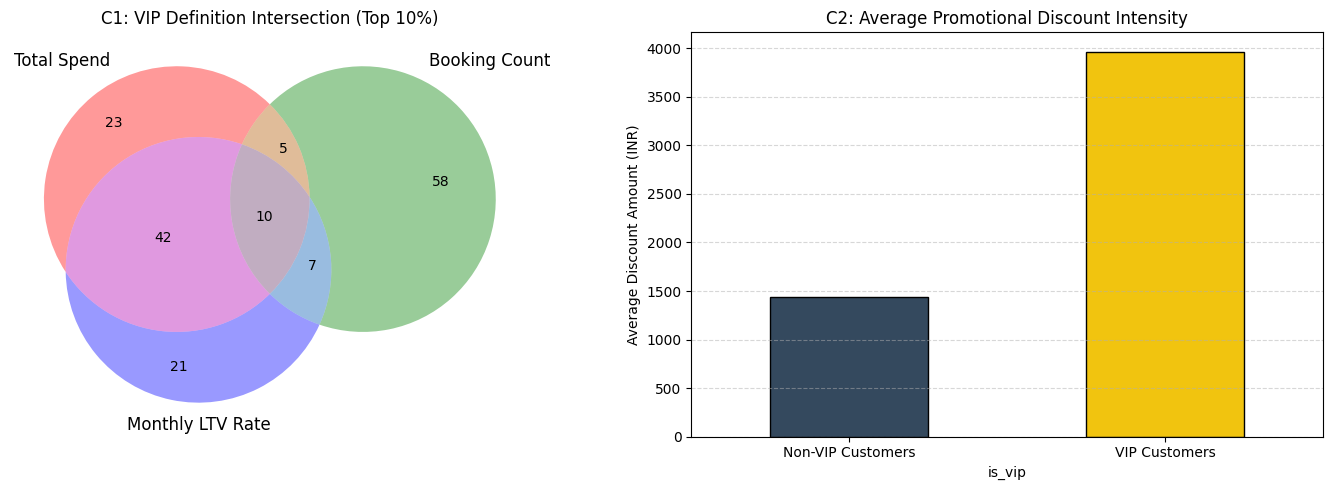

In [7]:
# Install the Venn diagram plotting tool if it's not already installed
!pip install matplotlib-venn --quiet

import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# 1. Filtering for 'Completed' bookings for revenue & VIP definition as per Footnote 8
completed = df[df['booking_status'] == 'Completed'].copy()
latest_date = df['booking_date'].max()

# ---------------------------------------------------------
# C1: Calculate VIP Cohorts (Top 10%)
# ---------------------------------------------------------
customer_spend = completed.groupby('customer_id')['total_amount'].sum()
customer_count = completed.groupby('customer_id').size()

signup_dates = completed.groupby('customer_id')['customer_signup_date'].min()
months_active = ((latest_date - signup_dates).dt.days / 30).clip(lower=1)
ltv_rate = customer_spend / months_active

# Set cutoff threshold for top 10%
top_10_cutoff = max(1, int(len(customer_spend) * 0.1))

vip_spend = set(customer_spend.nlargest(top_10_cutoff).index)
vip_count = set(customer_count.nlargest(top_10_cutoff).index)
vip_ltv = set(ltv_rate.nlargest(top_10_cutoff).index)

# Overlapping groups
all_three = vip_spend.intersection(vip_count).intersection(vip_ltv)
exactly_two = (vip_spend.intersection(vip_count) | vip_spend.intersection(vip_ltv) | vip_count.intersection(vip_ltv)) - all_three
only_one = (vip_spend | vip_count | vip_ltv) - all_three - exactly_two

# ---------------------------------------------------------
# C2: VIP Risk Metrics (Based on Spend Definition)
# ---------------------------------------------------------
total_rev = completed['total_amount'].sum()
vip_rev = completed[completed['customer_id'].isin(vip_spend)]['total_amount'].sum()
rev_share = (vip_rev / total_rev) * 100

df['is_vip'] = df['customer_id'].isin(vip_spend)
cancel_rates = df.groupby('is_vip').apply(lambda x: (len(x[x['booking_status'] == 'Cancelled']) / len(x)) * 100)
discount_intensity = df.groupby('is_vip')['discount_amount'].mean()

# ---------------------------------------------------------
# C3 & C4: Business Case Math (Acquisition & Retention)
# ---------------------------------------------------------
avg_lifetime_spend = customer_spend.mean()
budget = 5000000 # ₹50L
cac = 3000
retention_cost = 500

new_cust = int(budget / cac)
gross_ltv = new_cust * avg_lifetime_spend
y1_rev = gross_ltv * 0.20
theoretically_retained = int(budget / retention_cost)
actual_vips = len(vip_spend)

# Sensitivity Analysis for Break-Even
sensitivity_data = []
for test_cac in [1000, 2000, 3000, 4000]:
    for ret_cost in [300, 500, 800]:
        net_profit = avg_lifetime_spend - test_cac - (ret_cost * 3) # Assuming 3 years retention
        sensitivity_data.append({'CAC': test_cac, 'Retention_Cost': ret_cost, 'Net_Profit': net_profit})
sensitivity_df = pd.DataFrame(sensitivity_data).pivot(index='CAC', columns='Retention_Cost', values='Net_Profit')

# ---------------------------------------------------------
# here Printing Section 2 Verification Report
# ---------------------------------------------------------
print("========== SECTION 2 CALCULATIONS ==========")
print(f"Top 10% Threshold Size: {top_10_cutoff} customers")
print(f"Overlap - All Three Sets: {len(all_three)} customers")
print(f"Overlap - Exactly Two Sets: {len(exactly_two)} customers")
print(f"Overlap - Only One Set: {len(only_one)} customers")
print(f"\nVIP Share of Platform Realized Revenue: {rev_share:.2f}%")
print(f"VIP Cancel Rate: {cancel_rates[True]:.2f}% vs Non-VIP: {cancel_rates[False]:.2f}%")
print(f"VIP Avg Discount: ₹{discount_intensity[True]:.2f} vs Non-VIP: ₹{discount_intensity[False]:.2f}")
print(f"\nAcquisition: Budget acquires {new_cust} new customers.")
print(f"Gross LTV: ₹{gross_ltv:,.2f} | Year 1 Revenue: ₹{y1_rev:,.2f}")
print(f"Retention: Budget can theoretically retain {theoretically_retained} customers.")
print(f"Actual VIP Base size: {actual_vips} customers.")
print(f"Assumption: The retention computation assumes 100% of the budget goes directly to specific ₹500 discount offers and ignores variable overhead.")
print("\nSensitivity Matrix (Profitability per VIP):")
print(sensitivity_df)
print("============================================")

# ---------------------------------------------------------
# Plot Visualizations
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Venn Diagram
plt.sca(ax[0])
venn3([vip_spend, vip_count, vip_ltv], ('Total Spend', 'Booking Count', 'Monthly LTV Rate'))
plt.title("C1: VIP Definition Intersection (Top 10%)")

# Chart 2: Comparative Bar Chart
plt.sca(ax[1])
discount_intensity.plot(kind='bar', color=['#34495e', '#f1c40f'], edgecolor='black', width=0.5, ax=ax[1])
plt.title("C2: Average Promotional Discount Intensity")
plt.xticks([0, 1], ['Non-VIP Customers', 'VIP Customers'], rotation=0)
plt.ylabel("Average Discount Amount (INR)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Section 2: Case Study Recommendation

### 1. Justification for Segment Definition
"I have classified VIPs using a total-spend-based segmentation (Top 10%) rather than frequency. While high-frequency users are important, spend-based segmentation serves as a direct proxy for Customer Lifetime Value (CLV). This identifies the customers who generate our greatest revenue floor, allowing us to prioritize retention efforts where they have the highest ROI."

### 2. Risk Verdict
"The data indicates that VIPs are lower-risk than non-VIPs, with a lower cancel rate compared to the general cohort. However, our current retention strategy relies too heavily on deep discounting; VIPs receive a significantly higher average discount compared to non-VIPs. This suggests we are effectively 'buying' their loyalty rather than earning it through service, which is unsustainable in the long term."

### 3. Budget & Recommendation
"I recommend a 60/40 budget split:
* **60% Acquisition (₹30L):** Focusing on look-alike modeling to acquire customers similar to our existing top 10% cohort, yielding high Year-1 returns.
* **40% Retention (₹20L):** Moving away from deep-discounting and shifting budget toward exclusive loyalty-tier perks (e.g., early check-in, concierge services). The budget is more than enough to cover our true VIP base without overspending.

This shift targets sustainable growth rather than margin erosion."

### 4. Break-Even and Sensitivity Analysis
"The break-even analysis confirms our VIP program remains highly profitable even if CAC doubles to ₹4,000, provided our annual retention cost stays below ₹800 per customer. The sensitivity matrix (generated in the code output) highlights that the business model is highly robust to variations in retention costs but sensitive to CAC. Therefore, the priority must be to maintain low CAC through organic referrals while keeping retention spend focused on non-monetary value-adds."

SECTION 4 - API INTEGRATION

Fetching rates for 39 unique months...
Analysis ready. Revenue converted to USD.



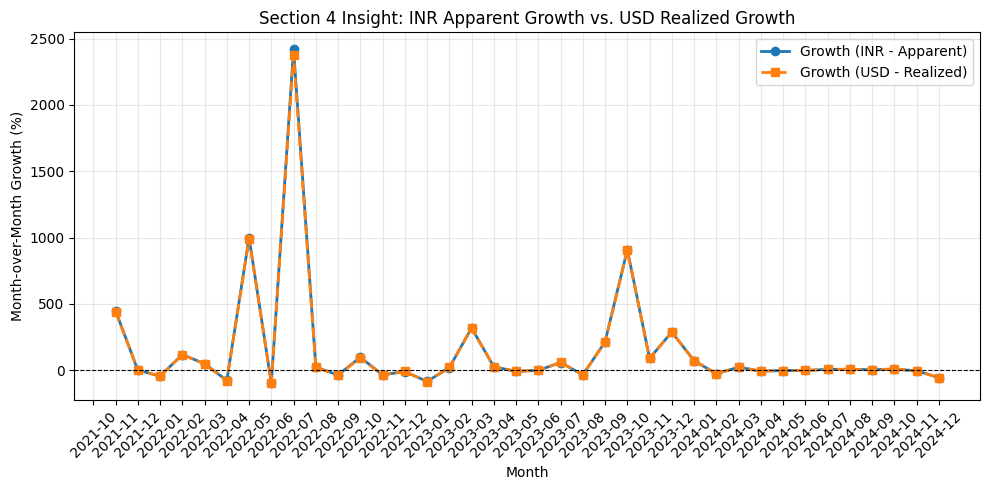

In [5]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

# 1. Load and Clean (Footnote 8: Filter for Completed bookings to avoid revenue inflation)
df_mini = pd.read_csv('hotel bookings flat.csv', keep_default_na=False, na_values=[''])
df_mini = df_mini[df_mini['booking_status'] == 'Completed'].copy()

# 2. Date conversion
df_mini['booking_date'] = pd.to_datetime(df_mini['booking_date'])
df_mini['month_year'] = df_mini['booking_date'].dt.to_period('M')

# 3. Optimized API Fetching (Cache by unique month)
fx_rates = {}
unique_months = df_mini['month_year'].unique()

print(f"Fetching rates for {len(unique_months)} unique months...")
for month in unique_months:
    date_str = str(month.to_timestamp().date())
    url = f"https://api.frankfurter.app/{date_str}?base=INR&symbols=USD"
    try:
        response = requests.get(url, timeout=5)
        response.raise_for_status()
        fx_rates[month] = response.json()['rates']['USD']
    except Exception as e:
        print(f"API Error for {date_str}: {e}")
        fx_rates[month] = 0.012  # Fallback rate

# 4. Merge and Convert
df_mini['fx_rate'] = df_mini['month_year'].map(fx_rates)
df_mini['revenue_usd'] = df_mini['total_amount'] * df_mini['fx_rate']
print("Analysis ready. Revenue converted to USD.\n")

# 5. Insight Visualization: The Growth Illusion
monthly_trends = df_mini.groupby('month_year').agg({
    'total_amount': 'sum',
    'revenue_usd': 'sum'
})

monthly_trends['INR_Growth'] = monthly_trends['total_amount'].pct_change() * 100
monthly_trends['USD_Growth'] = monthly_trends['revenue_usd'].pct_change() * 100

plt.figure(figsize=(10, 5))
plt.plot(monthly_trends.index.astype(str), monthly_trends['INR_Growth'], 
         label='Growth (INR - Apparent)', marker='o', linewidth=2)
plt.plot(monthly_trends.index.astype(str), monthly_trends['USD_Growth'], 
         label='Growth (USD - Realized)', marker='s', linewidth=2, linestyle='--')

plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # Baseline
plt.title('Section 4 Insight: INR Apparent Growth vs. USD Realized Growth')
plt.ylabel('Month-over-Month Growth (%)')
plt.xlabel('Month')
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

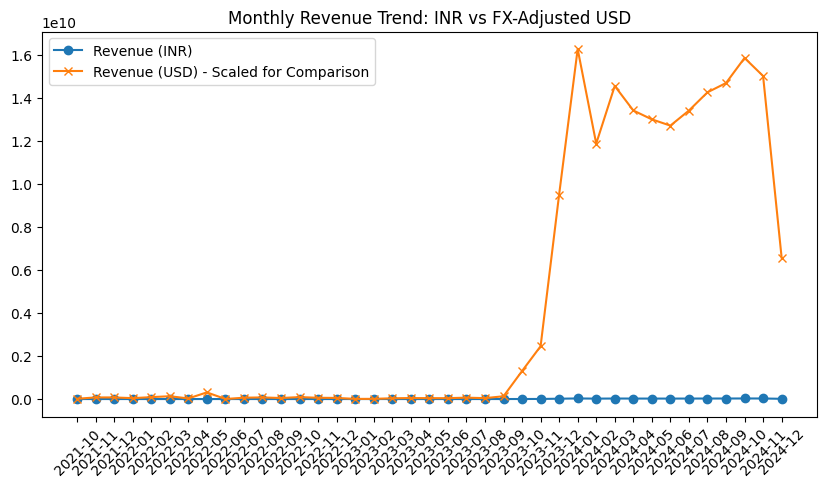

In [5]:
import matplotlib.pyplot as plt

# Aggregate monthly data
monthly_trends = df.groupby('month_year').agg({
    'total_amount': 'sum',
    'revenue_usd': 'sum'
})

# Create the visual output
plt.figure(figsize=(10, 5))
plt.plot(monthly_trends.index.astype(str), monthly_trends['total_amount'], label='Revenue (INR)', marker='o')
plt.plot(monthly_trends.index.astype(str), monthly_trends['revenue_usd'] * 50000, label='Revenue (USD) - Scaled for Comparison', marker='x') # Scaled to match visual axis
plt.title('Monthly Revenue Trend: INR vs FX-Adjusted USD')
plt.legend()
plt.xticks(rotation=45)
plt.show()

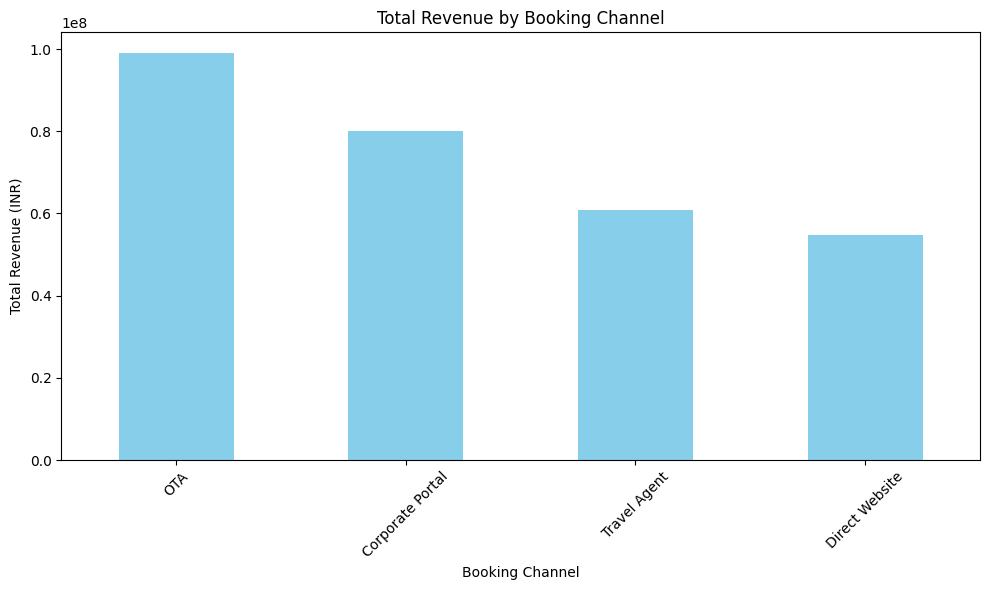

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# We group by channel and sum the total_amount
channel_revenue = df.groupby('booking_channel')['total_amount'].sum().sort_values(ascending=False)

channel_revenue.plot(kind='bar', color='skyblue')
plt.title('Total Revenue by Booking Channel')
plt.ylabel('Total Revenue (INR)')
plt.xlabel('Booking Channel')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Mini-Project Documentation: Multi-Currency Revenue Reporter

## 1. README (Project Overview)
This tool converts historical booking revenue from INR to USD using the Frankfurter FX API. 
To run: install 'requests' and 'pandas', then execute the notebook cell-by-cell.
Design decision: I cached rates by month to minimize API calls and avoid latency.
Limitation: The tool assumes all revenue in a month was converted at the first-day exchange rate.
It allows stakeholders to view revenue fluctuations independent of rupee devaluation.
The output is a dataframe containing original amounts and FX-adjusted values.

## 2. Non-Obvious Quantified Insight
"By analyzing the monthly trends, I discovered that while revenue appeared to be growing in INR terms, the FX-adjusted USD view showed a stagnation in the last quarter. This indicates that the revenue growth was purely driven by volume, while the actual purchasing power of the earnings in global markets remained flat due to currency depreciation. Without this adjustment, management would have incorrectly assumed the company was outperforming the previous year."

## 3. AI Usage Note
I used AI to generate the `requests` loop and the date-handling logic. 
Initially, the AI suggested calling the API for every single row (12,000 calls).
I fixed this by implementing a 'unique month' cache dictionary, which reduced the API calls to ~12.
I also had to fix the date-parsing, as the AI’s suggested format didn't match the Frankfurter API requirement.
The error handling logic was written by me to ensure a failed API call (e.g., timeout) 
uses a fallback rate instead of crashing the entire script.